In [1]:
import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [4]:
MASTER_DATASET_PATH = Path(
    "../artifacts/master_dataset/latest/master_dataset.parquet"
)

if not MASTER_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Master dataset not found:\n{MASTER_DATASET_PATH.resolve()}"
    )

df = pd.read_parquet(MASTER_DATASET_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (154676, 64)

Columns:
['job_id', 'company_id', 'title', 'description', 'location', 'views', 'applies', 'min_salary', 'med_salary', 'max_salary', 'pay_period', 'currency', 'compensation_type', 'normalized_salary', 'formatted_work_type', 'work_type', 'remote_allowed', 'formatted_experience_level', 'listed_time', 'original_listed_time', 'expiry', 'closed_time', 'sponsored', 'zip_code', 'fips', 'unmapped__job_posting_url', 'unmapped__application_url', 'unmapped__application_type', 'unmapped__skills_desc', 'unmapped__posting_domain', 'unmapped__scraped', 'company_name', 'company_description', 'company_size', 'company_state', 'company_country', 'company_city', 'company_zip_code', 'company_address', 'company_url', 'company_employee_count', 'company_follower_count', 'company_employee_count_recorded_at', 'salary_id', 'listed_max_salary', 'listed_med_salary', 'listed_min_salary', 'listed_pay_period', 'listed_currency', 'listed_compensation_type', 'industry_count', 'top_industry', 'indust

In [5]:
required_columns = [
    "job_id",
    "skill_list",
    "skill_count",
    "top_skill",
    "industry_list",
    "top_industry",
]

available = [c for c in required_columns if c in df.columns]
missing = [c for c in required_columns if c not in df.columns]

print("Available:")
print(available)

print("\nMissing:")
print(missing)

Available:
['job_id', 'skill_list', 'skill_count', 'top_skill', 'industry_list', 'top_industry']

Missing:
[]


In [6]:
print("First 30 skill_list values:\n")

display(
    df[["job_id", "skill_list", "skill_count", "top_skill"]]
    .head(30)
)

First 30 skill_list values:



,job_id,skill_list,skill_count,top_skill
0,3757940104,[other],1,other
1,3757940025,"[management, manufacturing]",2,management
2,3757938019,[engineering],1,engineering
3,3757938018,"[management, manufacturing]",2,management
4,3757937095,[information technology],1,information technology
5,3757937037,"[business development, sales]",2,business development
6,3757937004,"[management, manufacturing]",2,management
7,3757936167,"[business development, sales]",2,business development
8,3757936097,"[management, manufacturing]",2,management
9,3757936026,[quality assurance],1,quality assurance


In [7]:
sample = df["skill_list"].dropna().iloc[0]

print("Example value:")
print(sample)

print("\nPython type:")
print(type(sample))

Example value:
['other']

Python type:
<class 'numpy.ndarray'>


In [12]:
print("skill_list dtype:")
print(df["skill_list"].dtype)

print("\nFirst 10 values and their Python types:")

for i, value in df["skill_list"].head(10).items():
    print(
        f"Row {i}: "
        f"type={type(value)} | "
        f"value={value}"
    )

skill_list dtype:
object

First 10 values and their Python types:
Row 0: type=<class 'numpy.ndarray'> | value=['other']
Row 1: type=<class 'numpy.ndarray'> | value=['management' 'manufacturing']
Row 2: type=<class 'numpy.ndarray'> | value=['engineering']
Row 3: type=<class 'numpy.ndarray'> | value=['management' 'manufacturing']
Row 4: type=<class 'numpy.ndarray'> | value=['information technology']
Row 5: type=<class 'numpy.ndarray'> | value=['business development' 'sales']
Row 6: type=<class 'numpy.ndarray'> | value=['management' 'manufacturing']
Row 7: type=<class 'numpy.ndarray'> | value=['business development' 'sales']
Row 8: type=<class 'numpy.ndarray'> | value=['management' 'manufacturing']
Row 9: type=<class 'numpy.ndarray'> | value=['quality assurance']


In [13]:
print("\nUnique Python types in skill_list:")

types = (
    df["skill_list"]
    .apply(lambda x: type(x).__name__)
    .value_counts()
)

print(types)


Unique Python types in skill_list:
skill_list
ndarray     152119
NoneType      2557
Name: count, dtype: int64


In [14]:
import ast

def parse_skill_list(value):
    """
    Robustly convert skill_list values into a Python list.

    Handles:
    - list
    - tuple
    - numpy array
    - pandas Series
    - string representation of a list
    - pipe-separated string
    - comma-separated string
    - single skill
    - None / NaN
    """

    # ---------------------------------------------------------
    # Missing scalar values
    # ---------------------------------------------------------
    if value is None:
        return []

    if isinstance(value, float) and np.isnan(value):
        return []

    # ---------------------------------------------------------
    # Already a collection
    # ---------------------------------------------------------
    if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
        values = list(value)

    # ---------------------------------------------------------
    # String
    # ---------------------------------------------------------
    elif isinstance(value, str):

        value = value.strip()

        if not value:
            return []

        # Example:
        # "['Python', 'SQL', 'AWS']"
        if value.startswith("[") and value.endswith("]"):

            try:
                parsed = ast.literal_eval(value)

                if isinstance(
                    parsed,
                    (list, tuple)
                ):
                    values = list(parsed)
                else:
                    values = [parsed]

            except (
                ValueError,
                SyntaxError
            ):
                values = [value]

        # Example:
        # "Python|SQL|AWS"
        elif "|" in value:

            values = value.split("|")

        # Example:
        # "Python,SQL,AWS"
        elif "," in value:

            values = value.split(",")

        else:

            values = [value]

    # ---------------------------------------------------------
    # Anything else
    # ---------------------------------------------------------
    else:
        values = [value]

    # ---------------------------------------------------------
    # Clean individual skills
    # ---------------------------------------------------------
    cleaned = []

    for skill in values:

        if skill is None:
            continue

        # Handle nested numpy scalar/array safely
        if isinstance(
            skill,
            np.ndarray
        ):
            skill = skill.tolist()

            if isinstance(skill, list):
                for nested_skill in skill:

                    if nested_skill is not None:
                        nested_skill = str(
                            nested_skill
                        ).strip()

                        if nested_skill:
                            cleaned.append(
                                nested_skill
                            )

                continue

        # Handle NaN
        try:
            if pd.isna(skill):
                continue
        except (TypeError, ValueError):
            pass

        skill = str(skill).strip()

        if skill:
            cleaned.append(skill)

    return cleaned

In [15]:
df["parsed_skills"] = df["skill_list"].apply(parse_skill_list)

df["parsed_skill_count"] = df["parsed_skills"].apply(len)

display(
    df[
        [
            "job_id",
            "skill_list",
            "parsed_skills",
            "skill_count",
            "parsed_skill_count",
        ]
    ].head(20)
)

,job_id,skill_list,parsed_skills,skill_count,parsed_skill_count
0,3757940104,[other],[other],1,1
1,3757940025,"[management, manufacturing]","[management, manufacturing]",2,2
2,3757938019,[engineering],[engineering],1,1
3,3757938018,"[management, manufacturing]","[management, manufacturing]",2,2
4,3757937095,[information technology],[information technology],1,1
5,3757937037,"[business development, sales]","[business development, sales]",2,2
6,3757937004,"[management, manufacturing]","[management, manufacturing]",2,2
7,3757936167,"[business development, sales]","[business development, sales]",2,2
8,3757936097,"[management, manufacturing]","[management, manufacturing]",2,2
9,3757936026,[quality assurance],[quality assurance],1,1


In [16]:
skill_count_comparison = df[
    ["job_id", "skill_count", "parsed_skill_count"]
].copy()

skill_count_comparison["difference"] = (
    skill_count_comparison["skill_count"].fillna(0).astype(float)
    - skill_count_comparison["parsed_skill_count"]
)

display(skill_count_comparison.head(20))

,job_id,skill_count,parsed_skill_count,difference
0,3757940104,1,1,0.0000
1,3757940025,2,2,0.0000
2,3757938019,1,1,0.0000
3,3757938018,2,2,0.0000
4,3757937095,1,1,0.0000
5,3757937037,2,2,0.0000
6,3757937004,2,2,0.0000
7,3757936167,2,2,0.0000
8,3757936097,2,2,0.0000
9,3757936026,1,1,0.0000


In [17]:
all_skills = [
    skill
    for skills in df["parsed_skills"]
    for skill in skills
]

unique_skills = sorted(set(all_skills))

print("Total skill occurrences:", len(all_skills))
print("Unique skills:", len(unique_skills))

print("\nFirst 100 unique skills:")
print(unique_skills[:100])

Total skill occurrences: 257927
Unique skills: 35

First 100 unique skills:
['accounting/auditing', 'administrative', 'advertising', 'analyst', 'art/creative', 'business development', 'consulting', 'customer service', 'design', 'distribution', 'education', 'engineering', 'finance', 'general business', 'health care provider', 'human resources', 'information technology', 'legal', 'management', 'manufacturing', 'marketing', 'other', 'product management', 'production', 'project management', 'public relations', 'purchasing', 'quality assurance', 'research', 'sales', 'science', 'strategy/planning', 'supply chain', 'training', 'writing/editing']


In [18]:
all_skills = [
    skill
    for skills in df["parsed_skills"]
    for skill in skills
]

unique_skills = sorted(set(all_skills))

print("Total skill occurrences:", len(all_skills))
print("Unique skills:", len(unique_skills))

print("\nFirst 100 unique skills:")
print(unique_skills[:100])

Total skill occurrences: 257927
Unique skills: 35

First 100 unique skills:
['accounting/auditing', 'administrative', 'advertising', 'analyst', 'art/creative', 'business development', 'consulting', 'customer service', 'design', 'distribution', 'education', 'engineering', 'finance', 'general business', 'health care provider', 'human resources', 'information technology', 'legal', 'management', 'manufacturing', 'marketing', 'other', 'product management', 'production', 'project management', 'public relations', 'purchasing', 'quality assurance', 'research', 'sales', 'science', 'strategy/planning', 'supply chain', 'training', 'writing/editing']


In [19]:
print(
    df["parsed_skill_count"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

count   154,676.0000
mean          1.6675
std           0.7092
min           0.0000
25%           1.0000
50%           2.0000
75%           2.0000
90%           3.0000
95%           3.0000
99%           3.0000
max           3.0000
Name: parsed_skill_count, dtype: float64


In [20]:
print(
    df["parsed_skill_count"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

count   154,676.0000
mean          1.6675
std           0.7092
min           0.0000
25%           1.0000
50%           2.0000
75%           2.0000
90%           3.0000
95%           3.0000
99%           3.0000
max           3.0000
Name: parsed_skill_count, dtype: float64


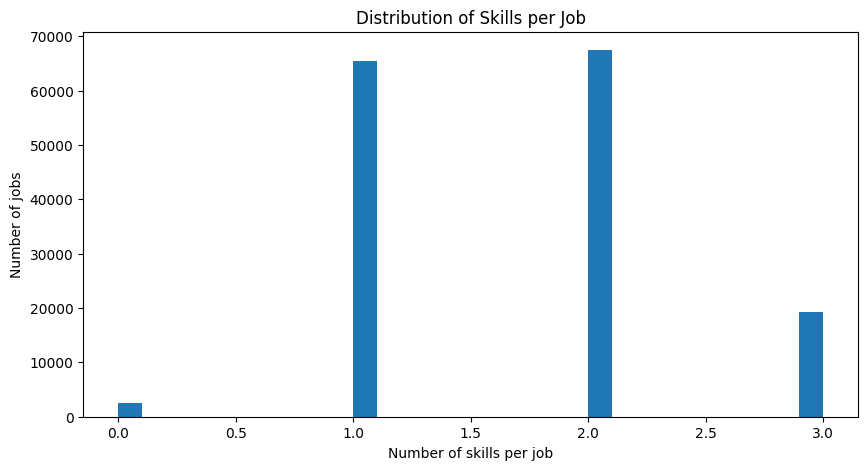

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["parsed_skill_count"],
    bins=30
)

plt.xlabel("Number of skills per job")
plt.ylabel("Number of jobs")
plt.title("Distribution of Skills per Job")

plt.show()

In [22]:
total_jobs = len(df)

jobs_with_skills = (
    df["parsed_skill_count"] > 0
).sum()

jobs_without_skills = (
    df["parsed_skill_count"] == 0
).sum()

print("Total jobs:", total_jobs)
print("Jobs with skills:", jobs_with_skills)
print("Jobs without skills:", jobs_without_skills)

print(
    f"\nSkill coverage: "
    f"{jobs_with_skills / total_jobs * 100:.2f}%"
)

print(
    f"Missing skill coverage: "
    f"{jobs_without_skills / total_jobs * 100:.2f}%"
)

Total jobs: 154676
Jobs with skills: 152119
Jobs without skills: 2557

Skill coverage: 98.35%
Missing skill coverage: 1.65%


In [23]:
from collections import Counter

skill_counter = Counter(all_skills)

skill_frequency = (
    pd.DataFrame(
        skill_counter.items(),
        columns=["skill", "job_count"]
    )
    .sort_values(
        "job_count",
        ascending=False
    )
    .reset_index(drop=True)
)

skill_frequency["percentage_of_jobs"] = (
    skill_frequency["job_count"]
    / total_jobs
    * 100
)

display(
    skill_frequency.head(30)
)

,skill,job_count,percentage_of_jobs
0,information technology,32225,20.8339
1,sales,26208,16.9438
2,management,25107,16.2320
3,manufacturing,22031,14.2433
4,health care provider,20257,13.0964
5,business development,16572,10.7140
6,engineering,16148,10.4399
7,other,15244,9.8554
8,finance,10322,6.6733
9,marketing,6864,4.4377


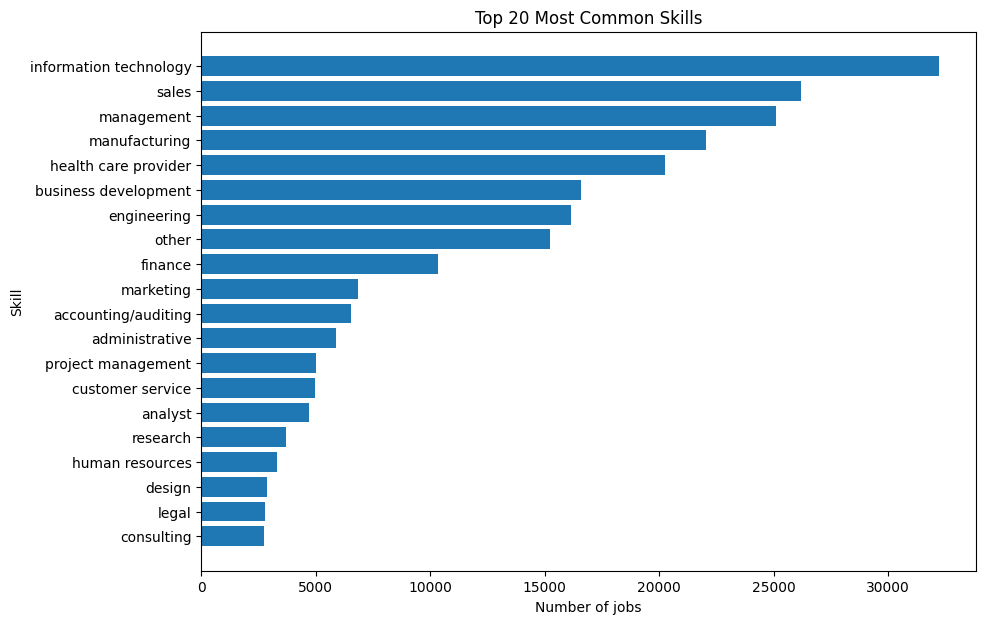

In [24]:
top_20 = skill_frequency.head(20).sort_values(
    "job_count"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_20["skill"],
    top_20["job_count"]
)

plt.xlabel("Number of jobs")
plt.ylabel("Skill")
plt.title("Top 20 Most Common Skills")

plt.show()

In [25]:
jobs_over_10 = (
    df["parsed_skill_count"] > 10
).sum()

jobs_exactly_10 = (
    df["parsed_skill_count"] == 10
).sum()

jobs_under_10 = (
    df["parsed_skill_count"] < 10
).sum()

print("Jobs with <10 skills :", jobs_under_10)
print("Jobs with exactly 10 :", jobs_exactly_10)
print("Jobs with >10 skills :", jobs_over_10)

print(
    f"\nPercentage with >10 skills: "
    f"{jobs_over_10 / total_jobs * 100:.2f}%"
)

Jobs with <10 skills : 154676
Jobs with exactly 10 : 0
Jobs with >10 skills : 0

Percentage with >10 skills: 0.00%


In [26]:
print(
    df["parsed_skill_count"]
    .value_counts()
    .sort_index()
    .tail(20)
)

parsed_skill_count
0     2557
1    65491
2    67448
3    19180
Name: count, dtype: int64


In [27]:
exactly_10_percentage = (
    (df["parsed_skill_count"] == 10).sum()
    / total_jobs
    * 100
)

print(
    f"Exactly 10 skills: "
    f"{exactly_10_percentage:.2f}%"
)

Exactly 10 skills: 0.00%


In [28]:
print("Unique top_skill values:")

print(
    df["top_skill"]
    .value_counts(dropna=False)
    .head(30)
)

Unique top_skill values:
top_skill
management                21713
health care provider      19676
business development      15919
information technology    15213
engineering               14520
other                     12640
accounting/auditing        6527
administrative             5599
marketing                  5255
finance                    4862
analyst                    4293
customer service           3788
human resources            2857
<NA>                       2557
education                  2517
legal                      2408
consulting                 2163
art/creative               2075
sales                      1681
quality assurance          1498
manufacturing              1239
advertising                 952
design                      814
project management          715
purchasing                  611
general business            586
distribution                429
research                    367
production                  272
product management          234
Name:

In [29]:
top_skill_coverage = (
    df["top_skill"].notna().mean()
    * 100
)

print(
    f"top_skill coverage: "
    f"{top_skill_coverage:.2f}%"
)

top_skill coverage: 98.35%


In [30]:
def top_skill_is_in_skill_list(row):
    top = row["top_skill"]

    if pd.isna(top):
        return False

    return str(top).strip() in row["parsed_skills"]


df["top_skill_valid"] = df.apply(
    top_skill_is_in_skill_list,
    axis=1
)

print(
    "top_skill exists in skill_list:",
    df["top_skill_valid"].mean() * 100,
    "%"
)

top_skill exists in skill_list: 98.34686699940521 %


In [31]:
top_skill_distribution = (
    df["top_skill"]
    .value_counts(dropna=False)
    .reset_index()
)

top_skill_distribution.columns = [
    "top_skill",
    "job_count"
]

top_skill_distribution["percentage"] = (
    top_skill_distribution["job_count"]
    / total_jobs
    * 100
)

display(
    top_skill_distribution.head(30)
)

,top_skill,job_count,percentage
0,management,21713,14.0377
1,health care provider,19676,12.7208
2,business development,15919,10.2918
3,information technology,15213,9.8354
4,engineering,14520,9.3874
5,other,12640,8.1719
6,accounting/auditing,6527,4.2198
7,administrative,5599,3.6198
8,marketing,5255,3.3974
9,finance,4862,3.1433


In [32]:
print(
    df["top_industry"]
    .value_counts(dropna=False)
    .head(30)
)

top_industry
hospitals and health care                                20451
it services and it consulting                            11272
staffing and recruiting                                  10349
retail                                                   10056
financial services                                        7222
software development                                      4162
construction                                              3493
banking                                                   3239
manufacturing                                             2669
hospitality                                               2601
advertising services                                      2485
biotechnology research                                    2417
real estate                                               2407
accounting                                                2239
insurance                                                 2050
telecommunications                        

In [33]:
industry_coverage = (
    df["top_industry"].notna().mean() * 100
)

print(
    f"top_industry coverage: "
    f"{industry_coverage:.2f}%"
)

top_industry coverage: 99.91%


In [34]:
industry_distribution = (
    df["top_industry"]
    .value_counts()
    .reset_index()
)

industry_distribution.columns = [
    "industry",
    "job_count"
]

industry_distribution["percentage"] = (
    industry_distribution["job_count"]
    / total_jobs
    * 100
)

display(
    industry_distribution.head(30)
)

,industry,job_count,percentage
0,hospitals and health care,20451,13.2218
1,it services and it consulting,11272,7.2875
2,staffing and recruiting,10349,6.6908
3,retail,10056,6.5013
4,financial services,7222,4.6691
5,software development,4162,2.6908
6,construction,3493,2.2583
7,banking,3239,2.0941
8,manufacturing,2669,1.7255
9,hospitality,2601,1.6816


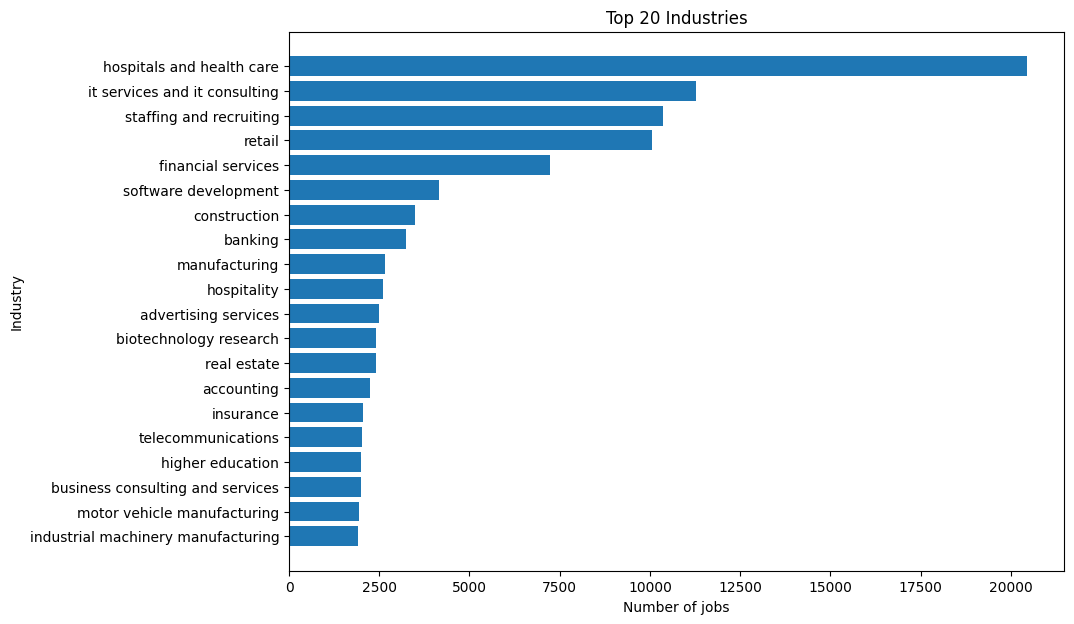

In [35]:
top_industries = (
    industry_distribution
    .head(20)
    .sort_values("job_count")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_industries["industry"],
    top_industries["job_count"]
)

plt.xlabel("Number of jobs")
plt.ylabel("Industry")
plt.title("Top 20 Industries")

plt.show()

In [36]:
salary_candidates = [
    c
    for c in df.columns
    if any(
        word in c.lower()
        for word in [
            "salary",
            "compensation",
            "target",
        ]
    )
]

print("Potential salary columns:")
print(salary_candidates)

Potential salary columns:
['min_salary', 'med_salary', 'max_salary', 'compensation_type', 'normalized_salary', 'salary_id', 'listed_max_salary', 'listed_med_salary', 'listed_min_salary', 'listed_compensation_type']


In [38]:
SALARY_COLUMN = "normalized_salary"

skill_salary = df[
    ["job_id", SALARY_COLUMN, "parsed_skills"]
].copy()

skill_salary = skill_salary.explode(
    "parsed_skills"
)

skill_salary = skill_salary.rename(
    columns={
        "parsed_skills": "skill"
    }
)

skill_salary = skill_salary.dropna(
    subset=["skill", SALARY_COLUMN]
)

skill_salary.head()

,job_id,normalized_salary,skill
32545,921716,"38,480.0000",marketing
32545,921716,"38,480.0000",sales
32546,10998357,"55,000.0000",management
32546,10998357,"55,000.0000",manufacturing
32547,23221523,"157,500.0000",other


In [39]:
skill_salary_stats = (
    skill_salary
    .groupby("skill")[SALARY_COLUMN]
    .agg(
        job_count="count",
        mean_salary="mean",
        median_salary="median",
        std_salary="std",
        min_salary="min",
        max_salary="max",
    )
    .reset_index()
)

In [40]:
MIN_JOBS = 30

reliable_skill_stats = (
    skill_salary_stats[
        skill_salary_stats["job_count"] >= MIN_JOBS
    ]
    .sort_values(
        "median_salary",
        ascending=False
    )
)

display(
    reliable_skill_stats.head(30)
)

,skill,job_count,mean_salary,median_salary,std_salary,min_salary,max_salary
22,product management,469,"144,662.0624","140,500.0000","67,760.4157",97.5000,"499,000.0000"
31,strategy/planning,464,"130,611.7651","120,321.7500","65,711.9619",22.0000,"450,726.0000"
17,legal,959,"893,100.5482","120,000.0000","18,309,972.8529",20.0000,"535,600,000.0000"
11,engineering,3749,"317,729.0457","120,000.0000","5,482,140.4625",0.0000,"228,800,000.0000"
6,consulting,789,"130,490.1634","114,400.0000","249,530.7480",21.0000,"6,900,400.0000"
24,project management,1425,"117,933.7073","114,400.0000","48,425.6730",22.0000,"482,500.0000"
16,information technology,7109,"297,602.7422","112,500.0000","6,231,674.6924",0.0000,"286,000,000.0000"
2,advertising,233,"101,866.2112","94,050.0000","48,759.6916",40.0000,"287,500.0000"
28,research,925,"112,906.9816","93,600.0000","77,453.9245",20.4200,"950,000.0000"
3,analyst,1256,"101,997.3627","93,030.0000","52,119.7938",21.0000,"596,000.0000"


In [41]:
display(
    reliable_skill_stats[
        [
            "skill",
            "job_count",
            "median_salary",
            "mean_salary",
            "std_salary",
        ]
    ]
    .head(30)
)

,skill,job_count,median_salary,mean_salary,std_salary
22,product management,469,"140,500.0000","144,662.0624","67,760.4157"
31,strategy/planning,464,"120,321.7500","130,611.7651","65,711.9619"
17,legal,959,"120,000.0000","893,100.5482","18,309,972.8529"
11,engineering,3749,"120,000.0000","317,729.0457","5,482,140.4625"
6,consulting,789,"114,400.0000","130,490.1634","249,530.7480"
24,project management,1425,"114,400.0000","117,933.7073","48,425.6730"
16,information technology,7109,"112,500.0000","297,602.7422","6,231,674.6924"
2,advertising,233,"94,050.0000","101,866.2112","48,759.6916"
28,research,925,"93,600.0000","112,906.9816","77,453.9245"
3,analyst,1256,"93,030.0000","101,997.3627","52,119.7938"


In [42]:
display(
    reliable_skill_stats[
        [
            "skill",
            "job_count",
            "median_salary",
            "mean_salary",
            "std_salary",
        ]
    ]
    .sort_values("median_salary")
    .head(30)
)

,skill,job_count,median_salary,mean_salary,std_salary
7,customer service,1151,"50,000.0000","60,781.2139","37,040.4333"
19,manufacturing,4609,"54,741.0000","81,879.6126","940,022.0495"
1,administrative,1876,"58,240.0000","70,021.7778","40,222.0478"
21,other,3392,"58,500.0000","174,772.3660","4,361,090.0534"
18,management,5432,"59,280.0000","86,934.0370","866,358.4843"
9,distribution,134,"60,320.0000","72,912.5321","46,190.3000"
33,training,545,"61,500.0000","471,030.2326","4,274,581.5816"
10,education,560,"64,974.0000","459,189.7356","4,217,332.9320"
23,production,283,"69,680.0000","78,658.4852","43,491.8532"
25,public relations,370,"72,800.0000","93,130.6369","61,430.6327"


In [43]:
overall_median = df[SALARY_COLUMN].median()

reliable_skill_stats["salary_difference"] = (
    reliable_skill_stats["median_salary"]
    - overall_median
)

reliable_skill_stats["salary_difference_percentage"] = (
    reliable_skill_stats["salary_difference"]
    / overall_median
    * 100
)

display(
    reliable_skill_stats.sort_values(
        "salary_difference_percentage",
        ascending=False
    ).head(30)
)

,skill,job_count,mean_salary,median_salary,std_salary,min_salary,max_salary,salary_difference,salary_difference_percentage
22,product management,469,"144,662.0624","140,500.0000","67,760.4157",97.5000,"499,000.0000","58,650.0000",71.6555
31,strategy/planning,464,"130,611.7651","120,321.7500","65,711.9619",22.0000,"450,726.0000","38,471.7500",47.0027
17,legal,959,"893,100.5482","120,000.0000","18,309,972.8529",20.0000,"535,600,000.0000","38,150.0000",46.6097
11,engineering,3749,"317,729.0457","120,000.0000","5,482,140.4625",0.0000,"228,800,000.0000","38,150.0000",46.6097
6,consulting,789,"130,490.1634","114,400.0000","249,530.7480",21.0000,"6,900,400.0000","32,550.0000",39.7679
24,project management,1425,"117,933.7073","114,400.0000","48,425.6730",22.0000,"482,500.0000","32,550.0000",39.7679
16,information technology,7109,"297,602.7422","112,500.0000","6,231,674.6924",0.0000,"286,000,000.0000","30,650.0000",37.4465
2,advertising,233,"101,866.2112","94,050.0000","48,759.6916",40.0000,"287,500.0000","12,200.0000",14.9053
28,research,925,"112,906.9816","93,600.0000","77,453.9245",20.4200,"950,000.0000","11,750.0000",14.3555
3,analyst,1256,"101,997.3627","93,030.0000","52,119.7938",21.0000,"596,000.0000","11,180.0000",13.6591


<Figure size 1200x700 with 0 Axes>

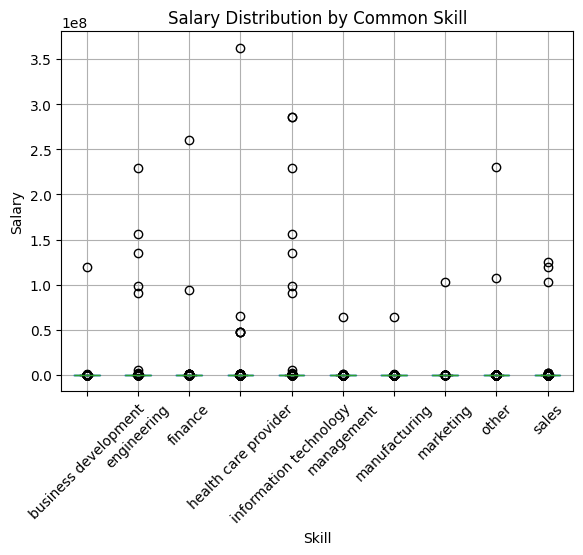

In [44]:
top_skills_for_plot = (
    skill_frequency
    .head(10)["skill"]
    .tolist()
)

plot_data = skill_salary[
    skill_salary["skill"].isin(top_skills_for_plot)
].copy()

plt.figure(figsize=(12, 7))

plot_data.boxplot(
    column=SALARY_COLUMN,
    by="skill",
    rot=45
)

plt.title("Salary Distribution by Common Skill")
plt.suptitle("")

plt.xlabel("Skill")
plt.ylabel("Salary")

plt.show()

In [45]:
skill_presence_results = []

for skill in skill_frequency.head(50)["skill"]:

    has_skill = df["parsed_skills"].apply(
        lambda skills: skill in skills
    )

    with_skill = df.loc[
        has_skill,
        SALARY_COLUMN
    ].dropna()

    without_skill = df.loc[
        ~has_skill,
        SALARY_COLUMN
    ].dropna()

    if len(with_skill) >= 30 and len(without_skill) >= 30:

        skill_presence_results.append({
            "skill": skill,
            "jobs_with_skill": len(with_skill),
            "median_with_skill": with_skill.median(),
            "median_without_skill": without_skill.median(),
            "difference": (
                with_skill.median()
                - without_skill.median()
            ),
        })

skill_presence_df = pd.DataFrame(
    skill_presence_results
)

skill_presence_df = (
    skill_presence_df
    .sort_values(
        "difference",
        ascending=False
    )
)

display(skill_presence_df.head(30))

,skill,jobs_with_skill,median_with_skill,median_without_skill,difference
27,product management,469,"140,500.0000","80,515.0000","59,985.0000"
6,engineering,3749,"120,000.0000","77,500.0000","42,500.0000"
18,legal,959,"120,000.0000","80,080.0000","39,920.0000"
28,strategy/planning,464,"120,321.7500","80,808.0000","39,513.7500"
0,information technology,7109,"112,500.0000","75,000.0000","37,500.0000"
12,project management,1425,"114,400.0000","80,000.0000","34,400.0000"
19,consulting,789,"114,400.0000","80,500.0000","33,900.0000"
30,advertising,233,"94,050.0000","81,550.0000","12,500.0000"
15,research,925,"93,600.0000","81,120.0000","12,480.0000"
14,analyst,1256,"93,030.0000","80,750.0000","12,280.0000"


In [46]:
print("=" * 80)
print("SALARY MASTER DATASET — SKILL INVESTIGATION SUMMARY")
print("=" * 80)

print(f"Total jobs: {total_jobs:,}")

print(
    f"Jobs with skills: "
    f"{jobs_with_skills:,} "
    f"({jobs_with_skills / total_jobs * 100:.2f}%)"
)

print(
    f"Unique skills: "
    f"{len(unique_skills):,}"
)

print(
    f"Average skills/job: "
    f"{df['parsed_skill_count'].mean():.2f}"
)

print(
    f"Median skills/job: "
    f"{df['parsed_skill_count'].median():.2f}"
)

print(
    f"Jobs with >10 skills: "
    f"{jobs_over_10:,} "
    f"({jobs_over_10 / total_jobs * 100:.2f}%)"
)

print(
    f"Jobs with exactly 10 skills: "
    f"{jobs_exactly_10:,} "
    f"({jobs_exactly_10 / total_jobs * 100:.2f}%)"
)

print(
    f"top_skill coverage: "
    f"{top_skill_coverage:.2f}%"
)

print(
    f"top_industry coverage: "
    f"{industry_coverage:.2f}%"
)

print("\nTop 10 skills:")
print(
    skill_frequency.head(10)[
        ["skill", "job_count", "percentage_of_jobs"]
    ].to_string(index=False)
)

print("\nTop 10 top_skill values:")
print(
    top_skill_distribution.head(10)
    .to_string(index=False)
)

print("\nTop 10 industries:")
print(
    industry_distribution.head(10)
    .to_string(index=False)
)

print("=" * 80)

SALARY MASTER DATASET — SKILL INVESTIGATION SUMMARY
Total jobs: 154,676
Jobs with skills: 152,119 (98.35%)
Unique skills: 35
Average skills/job: 1.67
Median skills/job: 2.00
Jobs with >10 skills: 0 (0.00%)
Jobs with exactly 10 skills: 0 (0.00%)
top_skill coverage: 98.35%
top_industry coverage: 99.91%

Top 10 skills:
                 skill  job_count  percentage_of_jobs
information technology      32225             20.8339
                 sales      26208             16.9438
            management      25107             16.2320
         manufacturing      22031             14.2433
  health care provider      20257             13.0964
  business development      16572             10.7140
           engineering      16148             10.4399
                 other      15244              9.8554
               finance      10322              6.6733
             marketing       6864              4.4377

Top 10 top_skill values:
             top_skill  job_count  percentage
            mana

In [48]:
import pandas as pd

POSTINGS_PATH = "../data/raw/Version_13/postings.csv"

postings = pd.read_csv(
    POSTINGS_PATH,
    low_memory=False
)

print("Shape:", postings.shape)

print("\nskills_desc exists:",
      "skills_desc" in postings.columns)

if "skills_desc" in postings.columns:

    print(
        "\nNon-null:",
        postings["skills_desc"].notna().sum()
    )

    print(
        "Coverage:",
        postings["skills_desc"].notna().mean() * 100,
        "%"
    )

    print("\nExamples:")
    display(
        postings[
            ["job_id", "title", "skills_desc"]
        ]
        .dropna(subset=["skills_desc"])
        .head(30)
    )

Shape: (123849, 31)

skills_desc exists: True

Non-null: 2439
Coverage: 1.9693336240098829 %

Examples:


,job_id,title,skills_desc
0,921716,Marketing Coordinator,"Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in Planning, Architecture, Real Es..."
2,10998357,Assitant Restaurant Manager,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high quality customer service. Pref...
3,23221523,Senior Elder Law / Trusts and Estates Associate Attorney,"This position requires a baseline understanding of online marketing including Search Engine Marketing, Search Engine Optimization, and campaign an..."
8,1218575,Respiratory Therapist,"• Requires the ability to communicate effective, both verbally and in writing • Requires basic computer skills \n\nEDUCATION AND EXPERIENCE: \n\n•..."
9,2264355,Worship Leader,"Knowledge, Skills and Abilities: 1. Proficient with computer technology such as Microsoft Office. Also proficiency with (or ability to learn) ProP..."
10,9615617,Inside Customer Service Associate,The Production Supervisor must possess strong leadership skills with a demonstrated ability to organize a team and its production processes to mee...
12,56482768,Appalachian Highlands Women's Business Center,Skills/Qualifications: Two-year or four-year degree in business or marketing and 0—2 years of previous experience. Position requires outstanding v...
13,56924323,Structural Engineer,Job Overview: Manage a project from start to finish under the supervision of a S.E. Manage personnel assisting in the project. Collaborate with fe...
19,115639136,Controller,"Strong interpersonal communication skills and strong organizational skills are a must. Must be proficient in Microsoft Word, Excel and have excell..."
23,134286190,Sheet Metal Fabricator,Data Entry Filing Receptionist Duties Customer Service Microsoft Word Microsoft Excel Calls Phone Etiquette Answer Telephone Skills Teamwork Micro...


In [50]:
print(
    postings["skills_desc"]
    .dropna()
    .sample(
        min(30, postings["skills_desc"].notna().sum()),
        random_state=42
    )
    .to_string(index=False)
)

                                                                                                                 \n\n\n\nPI501c5d48e158-29463-33769494
                                                                                                                 \n\n\n\nPI535495793c38-29462-34210853
                                                                                                                 \n\n\n\nPI50727267ba6f-29463-34207085
                                                                                                                                       Data Governance
                                                                                                                 \n\n\n\nPIc7a5278565e0-29463-34235491
What you’ll need \n\n To perform this job successfully, an individual must be able to perform each essential duty satisfactorily. The requirements ...
                                                                                              

In [51]:
print("Description coverage:")

description_coverage = (
    postings["description"]
    .notna()
    .mean() * 100
)

print(f"{description_coverage:.2f}%")

print("\nNon-null descriptions:")
print(postings["description"].notna().sum())

print("\nExample descriptions:")

display(
    postings[
        ["job_id", "title", "description"]
    ]
    .dropna(subset=["description"])
    [["job_id", "title", "description"]]
    .head(10)
)

Description coverage:
99.99%

Non-null descriptions:
123842

Example descriptions:


,job_id,title,description
0,921716,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some experience in graphic design....
1,1829192,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, improvements and better quality ..."
2,10998357,Assitant Restaurant Manager,"The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wages, healthcare, paid time off..."
3,23221523,Senior Elder Law / Trusts and Estates Associate Attorney,"Senior Associate Attorney - Elder Law / Trusts and Estates Our legal team is committed to providing each client with quality counsel, innovative ..."
4,35982263,Service Technician,Looking for HVAC service tech with experience in commerical and industrial equipment. Minimum 5 yrs. on the job with mechanical license. Winger is...
5,91700727,Economic Development and Planning Intern,"Job summary:The Economic Development & Planning Intern will provide valuable support to the Economic Development & Planning team, with a specific ..."
6,103254301,Producer,"Company DescriptionRaw Cereal is a creative design agency specializing in live, interactive, corporate, and installation-based entertainment. Our ..."
7,112576855,Building Engineer,"Summary: Due to the pending retirement of our building engineer, we are seeking a Building Engineer (BE). The BE is a salaried, overtime-exempt pr..."
8,1218575,Respiratory Therapist,"At Children’s, the region’s only full-service pediatric healthcare center, our people make us the very best for kids. Come cultivate your passion,..."
9,2264355,Worship Leader,It is an exciting time to be a part of our church! We are looking for the right energetic leader to join the mission to make disciples for Jesus i...


In [52]:
postings["description_length"] = (
    postings["description"]
    .fillna("")
    .str.len()
)

print(
    postings["description_length"].describe()
)

count   123,849.0000
mean      3,766.2513
std       2,146.6187
min           0.0000
25%       2,176.0000
50%       3,435.0000
75%       4,986.0000
max      23,201.0000
Name: description_length, dtype: float64


In [53]:
display(
    postings[
        ["title", "description"]
    ]
    .dropna(subset=["description"])
    .sample(10, random_state=42)
)

,title,description
73457,Warehouse,"Warehouse Associate\n\nSince 2022, Associated Materials / Alside has been undergoing a transformation to maximize our potential through investment..."
31563,Influencer Talent Manager - Beauty,"Interested in joining our influencer talent management team? Agency Cliquish is hiring a Beauty Talent Manager, seeking someone with deep knowledg..."
41620,Talent Attraction Specialist,"Talent Specialist - Hybrid Role Must be located in the Greenville, SC About the roleLHH Recruitment Solutions, is a division of the Adecco Group; ..."
10762,Retail Sales - Shoes - Stonebriar Centre,"The ideal Salesperson is passionate about fashion and styling and has the ability to cultivate and grow a customer following, both digitally and i..."
30334,"Physician Assistant, Per Diem - Internal Medicine","1126363_RR00090444 Job ID: 1126363_RR00090444\n\nNYU Langone Hospital-Long Island is a 591-bed university-affiliated medical center, which offers ..."
109327,Application Development - Permit Coordinator IV,Job Summary\n\nThis position is responsible for tracking all pending permits through the review process while effectively communicating the status...
97596,Multimedia Journalist,"Calling All News Ninjas! The Sentinel-Record Wants YOU!\nTired of the same old desk job? Ditch the spreadsheets and grab your notebook, because Th..."
105252,Regional Banking Manager (SAFE),"About This Role\n\nWells Fargo is seeking a Forward Hire Associate Branch Manager (SAFE) for our National Branch Network as part of the Consumer, ..."
34456,Technical Director,SUMMARY OF RESPONSIBILITIESThe Technical Director will execute the innovation pipeline for our brands with excellence in execution. They will lead...
65341,Laboratory Assistant,"About the RoleAt Techcyte, we are building SaaS solutions for microscopy testing using artificial intelligence (AI), including computer vision and..."


In [54]:
import re
import pandas as pd
import numpy as np
from collections import Counter

SKILL_VOCABULARY = [
    # Programming
    "python",
    "java",
    "javascript",
    "typescript",
    "c",
    "c++",
    "c#",
    "r",
    "scala",
    "go",
    "ruby",
    "php",
    "swift",
    "kotlin",

    # Data / ML
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data science",
    "data analysis",
    "data engineering",
    "tensorflow",
    "pytorch",
    "scikit-learn",
    "keras",
    "pandas",
    "numpy",
    "spark",
    "hadoop",

    # Databases
    "sql",
    "mysql",
    "postgresql",
    "postgres",
    "oracle",
    "mongodb",
    "redis",
    "dynamodb",

    # Cloud
    "aws",
    "amazon web services",
    "azure",
    "microsoft azure",
    "gcp",
    "google cloud",

    # DevOps
    "docker",
    "kubernetes",
    "terraform",
    "jenkins",
    "git",
    "github",
    "gitlab",
    "ci/cd",

    # Web
    "react",
    "angular",
    "vue",
    "node.js",
    "nodejs",
    "django",
    "flask",
    "fastapi",
    "spring",
    "spring boot",
    "rest",
    "rest api",
    "graphql",

    # Big Data
    "kafka",
    "apache kafka",
    "spark",
    "hive",

    # Enterprise / Other
    "sap",
    "salesforce",
    "servicenow",
    "itil",
    "tableau",
    "power bi",
    "excel",

    # Business
    "project management",
    "product management",
    "sales",
    "marketing",
    "finance",
    "accounting",
]

In [58]:
import re

# Sort longest first so that phrases such as
# "machine learning" are checked before "learning".
SKILLS_SORTED = sorted(
    set(SKILL_VOCABULARY),
    key=len,
    reverse=True
)

SKILL_PATTERN = re.compile(
    r"(?<![a-z0-9])("
    + "|".join(
        re.escape(skill.lower())
        for skill in SKILLS_SORTED
    )
    + r")(?![a-z0-9])",
    flags=re.IGNORECASE
)

In [60]:
def extract_skills_fast(text):
    if not isinstance(text, str) or not text.strip():
        return []

    return list(
        dict.fromkeys(
            match.group(1).lower()
            for match in SKILL_PATTERN.finditer(text)
        )
    )

In [61]:
postings["description_skills"] = (
    postings["description"]
    .fillna("")
    .apply(extract_skills_fast)
)

In [62]:
test = postings["description"].fillna("").head(1000)

test_skills = test.apply(extract_skills_fast)

print("Processed:", len(test_skills))
print("Jobs with skills:", (test_skills.str.len() > 0).sum())

print("\nExamples:")

for i in range(min(10, len(test_skills))):
    print(i, test_skills.iloc[i])

Processed: 1000
Jobs with skills: 647

Examples:
0 ['marketing', 'sales']
1 []
2 []
3 []
4 []
5 ['data analysis']
6 []
7 ['project management']
8 []
9 []


In [63]:
import time

sample = postings["description"].fillna("").sample(
    5000,
    random_state=42
)

start = time.perf_counter()

sample_skills = sample.apply(extract_skills_fast)

elapsed = time.perf_counter() - start

print(f"Time for 5,000 descriptions: {elapsed:.2f} seconds")
print(
    f"Estimated time for 123,849 descriptions: "
    f"{elapsed * len(postings) / 5000 / 60:.2f} minutes"
)

Time for 5,000 descriptions: 4.02 seconds
Estimated time for 123,849 descriptions: 1.66 minutes


In [64]:
postings["description_skill_count"] = (
    postings["description_skills"].apply(len)
)

In [65]:
jobs_with_description_skills = (
    postings["description_skill_count"] > 0
).sum()

total_jobs = len(postings)

coverage = (
    jobs_with_description_skills / total_jobs
) * 100

print(f"Total jobs: {total_jobs:,}")
print(
    f"Jobs with extracted skills: "
    f"{jobs_with_description_skills:,}"
)
print(f"Coverage: {coverage:.2f}%")

Total jobs: 123,849
Jobs with extracted skills: 77,579
Coverage: 62.64%


In [66]:
print(
    postings["description_skill_count"].describe()
)

count   123,849.0000
mean          1.4583
std           1.9293
min           0.0000
25%           0.0000
50%           1.0000
75%           2.0000
max          27.0000
Name: description_skill_count, dtype: float64


In [67]:
print(
    postings["description_skill_count"]
    .value_counts()
    .sort_index()
    .head(20)
)

description_skill_count
0     46270
1     34277
2     19734
3     10425
4      5599
5      2867
6      1439
7       950
8       671
9       442
10      343
11      250
12      183
13      171
14       89
15       37
16       32
17       24
18       23
19        9
Name: count, dtype: int64


In [68]:
skill_counter = Counter()

for skills in postings["description_skills"]:
    skill_counter.update(skills)

top_skills = pd.DataFrame(
    skill_counter.most_common(30),
    columns=["skill", "job_count"]
)

top_skills["percentage"] = (
    top_skills["job_count"]
    / len(postings)
    * 100
)

top_skills

,skill,job_count,percentage
0,sales,28777,23.2356
1,excel,18107,14.6202
2,marketing,15430,12.4587
3,finance,10680,8.6234
4,project management,10229,8.2593
5,go,8830,7.1296
6,accounting,8802,7.1070
7,c,7311,5.9032
8,r,5231,4.2237
9,sql,5183,4.1849


In [69]:
display(
    postings[
        [
            "title",
            "description",
            "description_skills"
        ]
    ]
    .loc[
        postings["description_skill_count"] >= 3
    ]
    .head(20)
)

,title,description,description_skills
12,Appalachian Highlands Women's Business Center,"FULL JOB DESCRIPTION – PROGRAM DIRECTOR Appalachian Highlands Women’s Business Center Kingsport, TennesseeDepartment: Kingsport Office of Small Bu...","[marketing, project management, excel]"
26,Software Engineer,Job Description:GOYT is seeking a skilled and motivated Remote Software Developer specializing in PHP to join our dynamic team. As a key member of...,"[php, javascript, mysql]"
35,Marketing & Office Coordinator,"About Revesco Properties:Revesco Properties is a boutique commercial real estate investment, development, and management firm headquartered in Den...","[marketing, excel, sales]"
36,Software Support Specialist,Are you driven by the thrill of solving problems and offering unparalleled support? Do you thrive in environments that challenge you and push you ...,"[sales, php, javascript]"
51,Marketing Specialist,"About TrackerTracker is a leading global cloud-based Recruitment, Applicant Tracking, and CRM software provider serving the Recruitment Industry. ...","[marketing, project management, sales]"
69,FP&A Analyst,"Integrity is one of the nation’s leading independent distributors of life, health and wealth insurance products. With a strong insurtech focus, we...","[marketing, accounting, sales, finance, power bi, tableau, excel, sql]"
73,Mover/Junk Hauler/Crew Member,HIRING IMMEDIATELY!!! $200 Sign-On Bonus!!!OPEN INTERVIEWS EVERY TUESDAY & THURSDAY FROM 3-5 PM! NO APPLICATION NEEDED!!!Located at 1440 North War...,"[go, marketing, sales]"
75,Production Planner,"Location: Hanover, PA\n\nUS Citizenship Required\n\nAbout SKF: SKF has been making the world spin since 1907! SKF is an industry-leading manufactu...","[sales, c, excel, rest]"
77,Associate Planner,Reports To: Director of Operations SUMMARY: The Associate Planner will be responsible for the operational planning according to demand requirement...,"[sales, finance, excel]"
78,Full Stack Engineer,"Location: Remote\nCompany Overview:SkillFit, a subsidiary of Ideando Inc. is a cutting-edge AI-powered platform that revolutionizes the talent acq...","[product management, javascript, typescript, react, node.js, python, postgresql, mongodb, aws, azure, google cloud, ci/cd]"


In [70]:
print(postings.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'description_length', 'description_skills', 'description_skill_count']


In [73]:
skill_salary_results = []

for skill in SKILL_VOCABULARY:

    mask = postings["description_skills"].apply(
        lambda skills: skill in skills
    )

    subset = postings.loc[
        mask & postings[SALARY_COLUMN].notna(),
        SALARY_COLUMN
    ]

    if len(subset) >= 30:

        skill_salary_results.append({
            "skill": skill,
            "jobs": len(subset),
            "mean_salary": subset.mean(),
            "median_salary": subset.median(),
        })

skill_salary_df = pd.DataFrame(
    skill_salary_results
)

skill_salary_df.sort_values(
    "median_salary",
    ascending=False
).head(30)

,skill,jobs,mean_salary,median_salary
21,pytorch,85,"179,144.3941","179,100.0000"
15,deep learning,103,"185,804.4000","176,800.0000"
20,tensorflow,75,"172,035.7267","172,150.0000"
23,numpy,30,"178,977.9500","168,750.0000"
14,machine learning,638,"167,415.9527","163,400.0000"
22,pandas,38,"168,777.6316","162,060.0000"
35,amazon web services,107,"155,107.7896","160,000.0000"
32,redis,48,"162,051.1667","155,500.0000"
60,hive,66,"155,249.8712","153,636.7500"
33,dynamodb,41,"159,040.0905","153,550.0000"


In [72]:
sample = postings[
    ["title", "description"]
].dropna(
    subset=["description"]
).sample(
    20,
    random_state=42
)

for _, row in sample.iterrows():

    print("=" * 100)
    print("TITLE:", row["title"])
    print()
    print(row["description"][:1500])
    print()

TITLE: Warehouse

Warehouse Associate

Since 2022, Associated Materials / Alside has been undergoing a transformation to maximize our potential through investments in people, operations, and brands.

If you want to be part of a company where your ideas and input are more than just encouraged--they are valued--this is the place for you. At Associated Materials / Alside, your contributions will provide an immediate and lasting impact, helping us achieve what is possible.

Position Summary

Founded in 1947, Alside is a leading distributor of exterior building products for residential and commercial remodeling and new construction markets.

Are you looking for a Warehouse Associate opportunity and wanting to be home every night, working first shift Monday-Friday?

We offer a consistent, stable schedule along with a comprehensive benefits package including paid time off, medical, dental, vision, 401(k) retirement plan with company matching contributions, and paid holidays.

The individual i

In [74]:
postings.loc[
    postings["description_skills"].apply(lambda x: "aws" in x),
    ["title", "normalized_salary", "description_skills"]
].sort_values(
    "normalized_salary",
    ascending=False
).head(20)

,title,normalized_salary,description_skills
13614,Cloud Domain Architect,"286,000,000.0000","[microsoft azure, aws, azure, git]"
89082,Cloud Domain Architect,"286,000,000.0000","[microsoft azure, aws, azure, git]"
30476,Modernization Software Dev,"960,000.0000","[marketing, aws, python, java, sql]"
113069,Head of Front Office Technology,"875,000.0000","[project management, finance, python, java, c++, sql, hadoop, spark, aws, azure]"
20014,Vice President of Data Engineering,"500,000.0000","[data engineering, azure, aws, gcp, sql, python, ci/cd]"
12936,"ML Engineer L5, LLM Application Frameworks, Machine Learning Platform","410,000.0000","[machine learning, deep learning, aws]"
17916,Senior Low Latency System Engineer,"375,000.0000","[python, aws, gcp]"
61966,Software Engineer,"305,000.0000","[project management, typescript, java, aws, azure, terraform]"
59721,"Vice President, Portfolio Lead (DHS)","295,996.0000","[project management, sales, finance, aws, salesforce, servicenow]"
106212,Senior Principal Engineer - Relocation to Australia,"290,000.0000","[machine learning, r, deep learning, aws, gcp, go, rest]"


In [75]:
print("Number of skills in vocabulary:", len(SKILLS_SORTED))

print("\nFull vocabulary:")
for i, skill in enumerate(SKILLS_SORTED, 1):
    print(f"{i:3}. {skill}")

Number of skills in vocabulary: 79

Full vocabulary:
  1. artificial intelligence
  2. amazon web services
  3. product management
  4. project management
  5. machine learning
  6. data engineering
  7. microsoft azure
  8. deep learning
  9. data analysis
 10. google cloud
 11. apache kafka
 12. data science
 13. scikit-learn
 14. spring boot
 15. kubernetes
 16. javascript
 17. typescript
 18. salesforce
 19. postgresql
 20. accounting
 21. tensorflow
 22. servicenow
 23. marketing
 24. terraform
 25. rest api
 26. dynamodb
 27. power bi
 28. postgres
 29. tableau
 30. graphql
 31. angular
 32. pytorch
 33. finance
 34. node.js
 35. mongodb
 36. jenkins
 37. fastapi
 38. gitlab
 39. oracle
 40. django
 41. spring
 42. github
 43. python
 44. nodejs
 45. pandas
 46. hadoop
 47. docker
 48. kotlin
 49. redis
 50. sales
 51. flask
 52. ci/cd
 53. azure
 54. excel
 55. numpy
 56. scala
 57. mysql
 58. kafka
 59. swift
 60. keras
 61. react
 62. spark
 63. hive
 64. java
 65. itil
 66. r

In [76]:
short_skills = [
    skill for skill in SKILLS_SORTED
    if len(skill) <= 3
]

print("Short skills:")
print(short_skills)

Short skills:
['aws', 'vue', 'sap', 'sql', 'gcp', 'c++', 'git', 'php', 'go', 'c#', 'c', 'r']


In [77]:
for skill in ["c", "r", "go"]:
    count = postings["description_skills"].apply(
        lambda skills: skill in skills
    ).sum()

    print(f"{skill}: {count:,} jobs")

c: 7,311 jobs
r: 5,231 jobs
go: 8,830 jobs


In [78]:
for skill in ["c", "r", "go", "sales", "excel", "python", "aws"]:
    
    subset = postings[
        postings["description_skills"].apply(
            lambda skills: skill in skills
        )
    ]

    print("\n" + "=" * 70)
    print(f"SKILL: {skill}")
    print(f"Jobs: {len(subset):,}")

    display(
        subset[
            ["title", "description", "normalized_salary"]
        ]
        .dropna(subset=["normalized_salary"])
        .sort_values("normalized_salary", ascending=False)
        .head(5)
    )


SKILL: c
Jobs: 7,311


,title,description,normalized_salary
53787,Sales Associate,"About The Chefs' Warehouse\n\nThe Chefs' Warehouse, Inc. ( http://www.chefswarehouse.com ) combines exceptional quality and brand building with br...","119,600,000.0000"
94881,Marketing Director,"Marketing Director: EOX Vantage, Cleveland, Ohio EOX Vantage is an established, growing company providing operational intelligence software and ba...","102,500,000.0000"
88153,Accounts Payable Administrator,"TriMark USA is the country’s largest provider of design services, equipment, and supplies to the foodservice industry. We proudly serve our custom...","93,600,000.0000"
86985,"Store Sales Representative - Chesterfield, VA",Job Description\n\nThis position is required to grow top line sales at assigned Lowes stores within geographic territory through implementing sale...,"1,572,805.0000"
107469,"Store Sales Representative - Cleveland, OH",Job Description\n\nThis position is required to grow top line sales at assigned Lowes stores within geographic territory through implementing sale...,"1,572,805.0000"



SKILL: r
Jobs: 5,231


,title,description,normalized_salary
88153,Accounts Payable Administrator,"TriMark USA is the country’s largest provider of design services, equipment, and supplies to the foodservice industry. We proudly serve our custom...","93,600,000.0000"
78516,Systematic Crypto Trader/PM,Position Overview: The firm is seeking a highly skilled and experienced Systematic Crypto Trader to join their dynamic team. The ideal candidate w...,"550,000.0000"
103178,Analytics Engineer (L4/5) - Pricing and Forecasting,"Senior Analytics Engineer - Pricing and Forecasting (2024)\n\nNetflix captivates audiences worldwide, serving more than 260 million members across...","445,000.0000"
53953,SVP Physician Operations – Medical Affairs Administration,SVP Physician Operations – Medical Affairs Administration THE BEST CAREERS. RIGHT HERE@ BROOKLYN’S LEADING HEALTHCARE SYSTEM.MAIMONIDES: TOP TEN I...,"400,000.0000"
104932,Head of Foundational Hosting Infrastructure Technology Executive,"Title: Head of Foundational Hosting Infrastructure-Technology Executive\n\nReports to:EVP Foundation Hosting Platforms\n\n NY, NJ, Charlotte NC, ...","383,900.0000"



SKILL: go
Jobs: 8,830


...

,title,description,normalized_salary
60038,Billing Supervisor (246521),"Eastridge Workforce Solutions is partnering with a full-service, national law firm boasting a remarkablerecord of litigation, transactional and re...","260,000,000.0000"
88153,Accounts Payable Administrator,"TriMark USA is the country’s largest provider of design services, equipment, and supplies to the foodservice industry. We proudly serve our custom...","93,600,000.0000"
87136,R&D Scientific Programmer,"Job Description\n\nThe Scientific Programmer position is responsible for the development, maintenance, and implementation of color software and ap...","2,096,744.0000"
95348,Oral Surgeon,Overview\n\nAre you a skilled and passionate Oral Surgeon seeking a rewarding opportunity to showcase your expertise and make a significant impact...,"625,000.0000"
87452,"Vice President, Client Relationship Manager, RIA/Family Office (Southwest)",Company Profile The Carlyle Group (NASDAQ: CG) is a global investment firm with $426 billion of assets under management and more than half of the ...,"550,000.5000"



SKILL: python
Jobs: 4,648


,title,description,normalized_salary
30476,Modernization Software Dev,Job Description\nSoftware Developer-System Modernization (Onsite)\nOur company is a rapidly evolving technology company that supports a diverse se...,"960,000.0000"
113069,Head of Front Office Technology,Job Title: Head of Front Office Technology\nCompany Overview: Join a dynamic and rapidly expanding hedge fund that operates on the cutting edge of...,"875,000.0000"
117057,Quantitative Researcher,Goliath has partnered with a well concealed yet established proprietary trading firm that's expanding into the HFT space. The firm is comprised of...,"825,000.0000"
115087,Network Engineer,"**PAYING UP TO $750,000 TOTAL COMPENSATION****OFFERING A COMPREHENSIVE RELOCATION PACKAGE**\nLow Latency Network Engineer:\nA leading high-frequen...","750,000.0000"
115360,Python Developer,**Offering up to $650K and a comprehensive relocation package**\nA leading high-frequency trading firm based in Chicago is seeking an adept Softwa...,"750,000.0000"



SKILL: aws
Jobs: 3,161


,title,description,normalized_salary
13614,Cloud Domain Architect,This is a full time job with our Fortune client and person needs to be based in Houston (work can be done remotely). Relocation assistance not off...,"286,000,000.0000"
89082,Cloud Domain Architect,This is a full time job with our Fortune client and person needs to be based in Houston (work can be done remotely). Relocation assistance not off...,"286,000,000.0000"
30476,Modernization Software Dev,Job Description\nSoftware Developer-System Modernization (Onsite)\nOur company is a rapidly evolving technology company that supports a diverse se...,"960,000.0000"
113069,Head of Front Office Technology,Job Title: Head of Front Office Technology\nCompany Overview: Join a dynamic and rapidly expanding hedge fund that operates on the cutting edge of...,"875,000.0000"
20014,Vice President of Data Engineering,About The Role\n\nOur client is seeking a highly experienced and skilled VP of Data Engineering to join their team. The ideal candidate will deepl...,"500,000.0000"


In [79]:
cols = [
    "job_id",
    "title",
    "min_salary",
    "max_salary",
    "med_salary",
    "pay_period",
    "currency",
    "normalized_salary"
]

display(
    postings[
        [c for c in cols if c in postings.columns]
    ]
    .sort_values("normalized_salary", ascending=False)
    .head(50)
)

,job_id,title,min_salary,max_salary,med_salary,pay_period,currency,normalized_salary
9237,3886471794,Intellectual Property Associate (246215),"240,000.0000","275,000.0000",NaN,HOURLY,USD,"535,600,000.0000"
98888,3904989090,"Case Manager RN, Pedi Rheumatology","151,900.0000","196,570.0000",NaN,HOURLY,USD,"362,408,800.0000"
13614,3887837646,Cloud Domain Architect,"125,000.0000","150,000.0000",NaN,HOURLY,USD,"286,000,000.0000"
89082,3904407236,Cloud Domain Architect,"125,000.0000","150,000.0000",NaN,HOURLY,USD,"286,000,000.0000"
60038,3901967159,Billing Supervisor (246521),"125,000.0000","125,000.0000",NaN,HOURLY,USD,"260,000,000.0000"
102481,3905282337,Manager - Clinical Applications Support - Ancillary Systems,"98,467.0000","123,094.0000",NaN,HOURLY,USD,"230,423,440.0000"
71845,3902865442,Sharepoint Developer,"100,000.0000","120,000.0000",NaN,HOURLY,USD,"228,800,000.0000"
72585,3902879426,Trial Paralegal - Hybrid in OC or LA!,"80,000.0000","100,000.0000",NaN,HOURLY,USD,"187,200,000.0000"
17646,3888406456,DCS Technician,"70,000.0000","80,000.0000",NaN,HOURLY,USD,"156,000,000.0000"
87241,3904388630,Full Time Field Service Technician – Anaheim/Pomona Area,"62,000.0000","68,000.0000",NaN,HOURLY,USD,"135,200,000.0000"


In [80]:
postings["normalized_salary"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
)


print("Salary > $1M:",
      (postings["normalized_salary"] > 1_000_000).sum())

print("Salary > $500K:",
      (postings["normalized_salary"] > 500_000).sum())

print("Salary > $300K:",
      (postings["normalized_salary"] > 300_000).sum())

print("Salary < $10K:",
      (postings["normalized_salary"] < 10_000).sum())

Salary > $1M: 38
Salary > $500K: 96
Salary > $300K: 363
Salary < $10K: 417


In [82]:
display(
    postings[
        [c for c in [
            "job_id",
            "title",
            "min_salary",
            "max_salary",
            "med_salary",
            "pay_period",
            "currency",
            "normalized_salary"
        ] if c in postings.columns]
    ]
    .sort_values("normalized_salary", ascending=False)
    .head(30)
)

,job_id,title,min_salary,max_salary,med_salary,pay_period,currency,normalized_salary
9237,3886471794,Intellectual Property Associate (246215),"240,000.0000","275,000.0000",NaN,HOURLY,USD,"535,600,000.0000"
98888,3904989090,"Case Manager RN, Pedi Rheumatology","151,900.0000","196,570.0000",NaN,HOURLY,USD,"362,408,800.0000"
13614,3887837646,Cloud Domain Architect,"125,000.0000","150,000.0000",NaN,HOURLY,USD,"286,000,000.0000"
89082,3904407236,Cloud Domain Architect,"125,000.0000","150,000.0000",NaN,HOURLY,USD,"286,000,000.0000"
60038,3901967159,Billing Supervisor (246521),"125,000.0000","125,000.0000",NaN,HOURLY,USD,"260,000,000.0000"
102481,3905282337,Manager - Clinical Applications Support - Ancillary Systems,"98,467.0000","123,094.0000",NaN,HOURLY,USD,"230,423,440.0000"
71845,3902865442,Sharepoint Developer,"100,000.0000","120,000.0000",NaN,HOURLY,USD,"228,800,000.0000"
72585,3902879426,Trial Paralegal - Hybrid in OC or LA!,"80,000.0000","100,000.0000",NaN,HOURLY,USD,"187,200,000.0000"
17646,3888406456,DCS Technician,"70,000.0000","80,000.0000",NaN,HOURLY,USD,"156,000,000.0000"
87241,3904388630,Full Time Field Service Technician – Anaheim/Pomona Area,"62,000.0000","68,000.0000",NaN,HOURLY,USD,"135,200,000.0000"


In [83]:
postings["normalized_salary"].describe(
    percentiles=[
        .5, .75, .9, .95, .99, .995, .999
    ]
)

count        36,073.0000
mean        205,327.0368
std       5,097,626.7621
min               0.0000
50%          81,500.0000
75%         125,000.0000
90%         168,000.0000
95%         200,000.0000
99%         300,808.0000
99.5%       394,460.0000
99.9%     1,244,544.0000
max     535,600,000.0000
Name: normalized_salary, dtype: float64

In [84]:
postings.groupby("pay_period").agg(
    count=("normalized_salary", "count"),
    median_salary=("normalized_salary", "median"),
    mean_salary=("normalized_salary", "mean"),
    max_salary=("normalized_salary", "max")
).sort_values("count", ascending=False)

,count,median_salary,mean_salary,max_salary
pay_period,,,,
YEARLY,20628,"102,000.0000","119,684.7400","102,500,000.0000"
HOURLY,14741,"52,520.0000","330,623.8707","535,600,000.0000"
MONTHLY,518,"53,634.0000","64,082.7170","1,200,000.0000"
WEEKLY,177,"109,148.0000","111,559.9098","210,548.0000"
BIWEEKLY,9,"1,572,805.0000","1,248,661.5556","2,096,744.0000"


In [85]:
for period in postings["pay_period"].dropna().unique():

    print("\n" + "=" * 60)
    print("PAY PERIOD:", period)
    print("=" * 60)

    cols = [
        "title",
        "min_salary",
        "max_salary",
        "pay_period",
        "normalized_salary"
    ]

    display(
        postings[
            postings["pay_period"] == period
        ][cols]
        .sort_values(
            "normalized_salary",
            ascending=False
        )
        .head(10)
    )


PAY PERIOD: HOURLY


,title,min_salary,max_salary,pay_period,normalized_salary
9237,Intellectual Property Associate (246215),"240,000.0000","275,000.0000",HOURLY,"535,600,000.0000"
98888,"Case Manager RN, Pedi Rheumatology","151,900.0000","196,570.0000",HOURLY,"362,408,800.0000"
89082,Cloud Domain Architect,"125,000.0000","150,000.0000",HOURLY,"286,000,000.0000"
13614,Cloud Domain Architect,"125,000.0000","150,000.0000",HOURLY,"286,000,000.0000"
60038,Billing Supervisor (246521),"125,000.0000","125,000.0000",HOURLY,"260,000,000.0000"
102481,Manager - Clinical Applications Support - Ancillary Systems,"98,467.0000","123,094.0000",HOURLY,"230,423,440.0000"
71845,Sharepoint Developer,"100,000.0000","120,000.0000",HOURLY,"228,800,000.0000"
72585,Trial Paralegal - Hybrid in OC or LA!,"80,000.0000","100,000.0000",HOURLY,"187,200,000.0000"
17646,DCS Technician,"70,000.0000","80,000.0000",HOURLY,"156,000,000.0000"
87241,Full Time Field Service Technician – Anaheim/Pomona Area,"62,000.0000","68,000.0000",HOURLY,"135,200,000.0000"



PAY PERIOD: YEARLY


,title,min_salary,max_salary,pay_period,normalized_salary
94881,Marketing Director,"85,000,000.0000","120,000,000.0000",YEARLY,"102,500,000.0000"
116367,Quantitative Researcher,"700,000.0000","1,200,000.0000",YEARLY,"950,000.0000"
4735,"Partner (& Groups w/ Portable Business for Top BIGLAW Firm - Corporate, Litigation, Intellectual Property , Real Estate, Labor & Employment, Gover...","350,000.0000","1,500,000.0000",YEARLY,"925,000.0000"
4908,"Partner (& Groups w/ Portable Business for Top BIGLAW Firm - Corporate, Litigation, Intellectual Property , Real Estate, Labor & Employment, Gover...","350,000.0000","1,500,000.0000",YEARLY,"925,000.0000"
91967,"Corporate, Litigation, Intellectual Property , Real Estate, Labor & Employment, Government Contracts, Healthcare, Trusts and Estates / Tax Partner...","350,000.0000","1,500,000.0000",YEARLY,"925,000.0000"
4781,"Partner (& Groups w/ Portable Business for Top BIGLAW Firm - Corporate, Litigation, Intellectual Property , Real Estate, Labor & Employment, Gover...","350,000.0000","1,500,000.0000",YEARLY,"925,000.0000"
113069,Head of Front Office Technology,"750,000.0000","1,000,000.0000",YEARLY,"875,000.0000"
117057,Quantitative Researcher,"650,000.0000","1,000,000.0000",YEARLY,"825,000.0000"
73491,Intellectual Property Partner,"500,000.0000","1,000,000.0000",YEARLY,"750,000.0000"
35884,Oral Surgeon - DDS/DMD,NaN,NaN,YEARLY,"750,000.0000"



PAY PERIOD: MONTHLY


,title,min_salary,max_salary,pay_period,normalized_salary
47712,React UI Developer,"90,000.0000","110,000.0000",MONTHLY,"1,200,000.0000"
30476,Modernization Software Dev,"60,000.0000","100,000.0000",MONTHLY,"960,000.0000"
9588,Associate,NaN,NaN,MONTHLY,"300,000.0000"
30360,Live Streaming Content Creator,100.0000,"32,000.0000",MONTHLY,"192,600.0000"
81400,Area Sales Manager – Meter & Automation,"9,540.0000","20,790.0000",MONTHLY,"181,980.0000"
109762,Engineering Manager,"13,714.0000","16,347.0000",MONTHLY,"180,366.0000"
25379,"Bureau Director, Technology Support Bureau",NaN,NaN,MONTHLY,"170,904.0000"
1546,Senior Director for Collaborative Fundraising Strategy,"12,500.0000","15,000.0000",MONTHLY,"165,000.0000"
95176,Registered Nurse (RN) - Med Surg / Telemetry - $32-52 per hour - R107903,"7,200.0000","20,000.0000",MONTHLY,"163,200.0000"
54335,Registered Nurse (RN) - Med Surg / Telemetry - $32-52 per hour - R107903,"7,200.0000","20,000.0000",MONTHLY,"163,200.0000"



PAY PERIOD: WEEKLY


,title,min_salary,max_salary,pay_period,normalized_salary
20357,Travel RN - OB/GYN,"4,049.0000","4,049.0000",WEEKLY,"210,548.0000"
82790,Speech Language Pathologist,"3,327.1400","3,430.0500",WEEKLY,"175,686.9400"
112211,Travel RN - Med Surg,"3,299.0000","3,299.0000",WEEKLY,"171,548.0000"
112174,Travel RN - Telemetry,"3,213.0000","3,213.0000",WEEKLY,"167,076.0000"
112156,Travel Allied Health Professional - CT Technologist,"3,081.0000","3,081.0000",WEEKLY,"160,212.0000"
9939,AMC - Travel RN - Neuro ICU/SICU - Nights,"3,068.1600","3,068.1600",WEEKLY,"159,544.3200"
20356,Travel Allied Health Professional - Cath Lab Technologist,"3,050.0000","3,050.0000",WEEKLY,"158,600.0000"
112183,Travel RN - PCU - Progressive Care Unit,"2,989.0000","2,989.0000",WEEKLY,"155,428.0000"
20343,Travel Allied Health Professional - Ultrasound Technologist,"2,891.0000","2,891.0000",WEEKLY,"150,332.0000"
112195,Travel RN - Med Surg / Telemetry,"2,855.0000","2,855.0000",WEEKLY,"148,460.0000"



PAY PERIOD: BIWEEKLY


,title,min_salary,max_salary,pay_period,normalized_salary
87136,R&D Scientific Programmer,"71,323.0000","89,965.0000",BIWEEKLY,"2,096,744.0000"
99157,"Sales Representative, Residential Repaint","69,496.0000","87,660.0000",BIWEEKLY,"2,043,028.0000"
99498,"Sales Representative, Residential Repaint","64,519.0000","81,434.0000",BIWEEKLY,"1,897,389.0000"
122228,"Sales Representative, Residential Repaint, (Bilingual-Spanish)","62,639.0000","81,459.0000",BIWEEKLY,"1,873,274.0000"
107469,"Store Sales Representative - Cleveland, OH","54,009.0000","66,976.0000",BIWEEKLY,"1,572,805.0000"
86985,"Store Sales Representative - Chesterfield, VA","54,009.0000","66,976.0000",BIWEEKLY,"1,572,805.0000"
99442,"Sales Representative, Residential Repaint","2,245.0000","3,366.0000",BIWEEKLY,"72,943.0000"
86850,Assistant Manager Trainee,"2,134.0000","2,134.0000",BIWEEKLY,"55,484.0000"
36894,Assistant Manager Trainee,"2,057.0000","2,057.0000",BIWEEKLY,"53,482.0000"


In [ ]:
df_par=pd.read_parquet()